## Solución Taller 06- Optimización de Redes Metabólicas

In [1]:
# Librerías a utilizar en el taller
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import cobra
from dFBA import dFBA

# Definir Gurobi como solver
cobra.core.configuration.Configuration(solver="gurobi");

In [2]:
# Cargar el modelo que se utilizará en el taller
model = cobra.io.read_sbml_model("ecoli_core.xml")

Set parameter Username
Set parameter LicenseID to value 2596460
Academic license - for non-commercial use only - expires 2025-12-06


### Pregunta a)
Se solicita simular crecimiento considerando glucosa como sustrato limitante. Para ello, en primer lugar tenemos que identificar los índices de las reacciones importantes

In [3]:
# Se extrae el índice de la reacción de exchange de glucosa, oxígeno, etanol y acetato
oxygen_rxn             = "EX_o2(e)"
oxygen_exchange_index  = [i for i, rxn in enumerate(model.exchanges) if rxn.id == oxygen_rxn][0]

glucose_rxn            = "EX_glc(e)"
glucose_exchange_index = [i for i, rxn in enumerate(model.exchanges) if rxn.id == glucose_rxn][0]

acetate_rxn            = "EX_ac(e)"
acetate_exchange_index = [i for i, rxn in enumerate(model.exchanges) if rxn.id == acetate_rxn][0]

etanol_rxn            = "EX_etoh(e)"
etanol_exchange_index = [i for i, rxn in enumerate(model.exchanges) if rxn.id == etanol_rxn][0]


In [5]:
# Se permite el consumo de etanol como fuente secundaria
model.exchanges[etanol_exchange_index].lower_bound  =  0
model.exchanges[acetate_exchange_index].lower_bound = -20
model.exchanges[oxygen_exchange_index].lower_bound  = -20

Ahora se definen las condiciones de la simulación indicadas en el enunciado:

In [6]:
# Sustratos relevantes
limited_substrate = glucose_exchange_index
o2_index          = oxygen_exchange_index

# Parámetros de consumo de glucosa (Michaelis Menten)
v_max = 10   # Velocidad máxima de consumo
k_S   = 0.1  # Constante de saturación

# Concentraciones iniciales
Y0    = np.ones(len(model.exchanges) + 1) * 0 # Se inicializa el vector con 100 mM para todos los compuestos
# Y0[np.array(index_carbon_sources) + 1]  = 0.0   # No hay otras fuentes de carbono en el medio
Y0[0] = 0.01                        # Concentración de biomasa
Y0[limited_substrate + 1] = 40.0    # Concentración de glucosa
Y0[o2_index + 1] = 15               # Concentración de oxígeno
Y0[etanol_exchange_index + 1]  = 0 # Concentración de etanol
Y0[acetate_exchange_index + 1] = 0  # No hay acetato

# Tiempo de simulación
t_span = (0, 10)
t_eval = np.linspace(0, 10, 100)

# Llamado del algoritmo Dynamic Flux Balance Analysis
sol = dFBA(model, limited_substrate, o2_index, Y0, t_span, t_eval, (v_max, k_S))

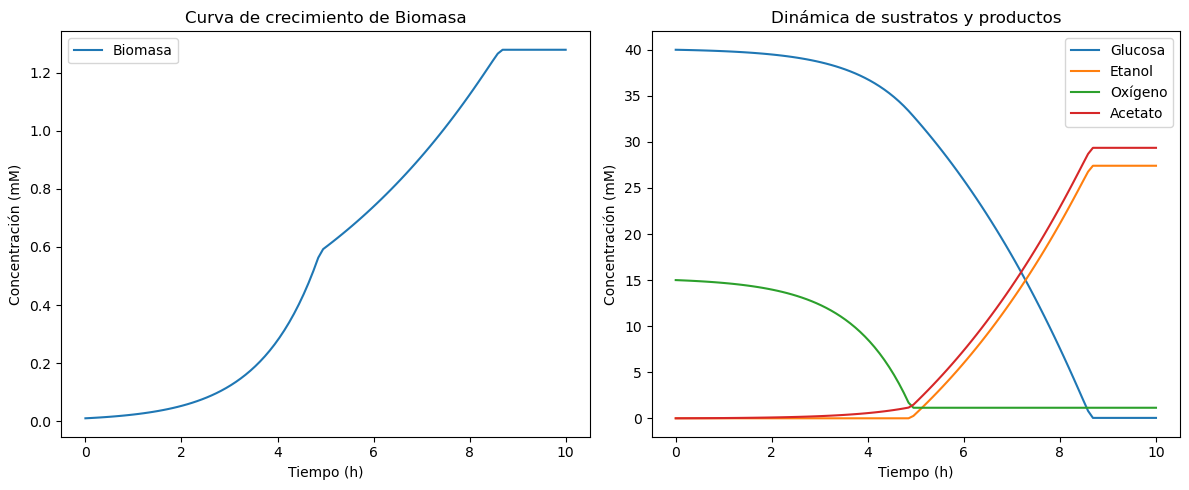

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: Biomasa y Glucosa
axs[0].plot(sol.t, sol.y[0], label='Biomasa')

axs[0].set_xlabel('Tiempo (h)')
axs[0].set_ylabel('Concentración (mM)')
axs[0].legend()
axs[0].set_title('Curva de crecimiento de Biomasa')

# Subplot 2: Oxígeno y Acetato
axs[1].plot(sol.t, sol.y[glucose_exchange_index + 1], label='Glucosa')
axs[1].plot(sol.t, sol.y[etanol_exchange_index + 1], label='Etanol')
axs[1].plot(sol.t, sol.y[oxygen_exchange_index + 1], label='Oxígeno')
axs[1].plot(sol.t, sol.y[acetate_exchange_index + 1], label='Acetato')
axs[1].set_xlabel('Tiempo (h)')
axs[1].set_ylabel('Concentración (mM)')
axs[1].legend()
axs[1].set_title('Dinámica de sustratos y productos')

plt.tight_layout()
plt.show()

### Pregunta b)

Se solicita repetir el procedimiento, pero ahora ocupando acetato como sustrato limitante. Por lo tanto, se debe bloquear el consumo de glucosa.

In [9]:
model.exchanges[glucose_exchange_index].lower_bound = 0
model.exchanges[acetate_exchange_index].lower_bound = -20

In [10]:
# Sustratos relevantes
limited_substrate = acetate_exchange_index
o2_index          = oxygen_exchange_index

# Parámetros de consumo de glucosa (Michaelis Menten)
v_max = 100   # Velocidad máxima de consumo
k_S   = 0.8  # Constante de saturación

# Concentraciones iniciales
Y0    = np.ones(len(model.exchanges) + 1) * 100 # Se inicializa el vector con 100 mM para todos los compuestos
# Y0[np.array(index_carbon_sources) + 1]  = 0.0   # No hay otras fuentes de carbono en el medio
Y0[0] = 0.01                        # Concentración de biomasa
Y0[limited_substrate + 1] = 40.0    # Concentración de acetato
Y0[o2_index + 1] = 15               # Concentración de oxígeno
Y0[etanol_exchange_index + 1]  = 0 # Concentración de etanol
Y0[glucose_exchange_index + 1] = 0  # No hay glucosa

# Tiempo de simulación
t_span = (0, 10)
t_eval = np.linspace(0, 10, 100)

# Llamado del algoritmo Dynamic Flux Balance Analysis
sol = dFBA(model, limited_substrate, o2_index, Y0, t_span, t_eval, (v_max, k_S))

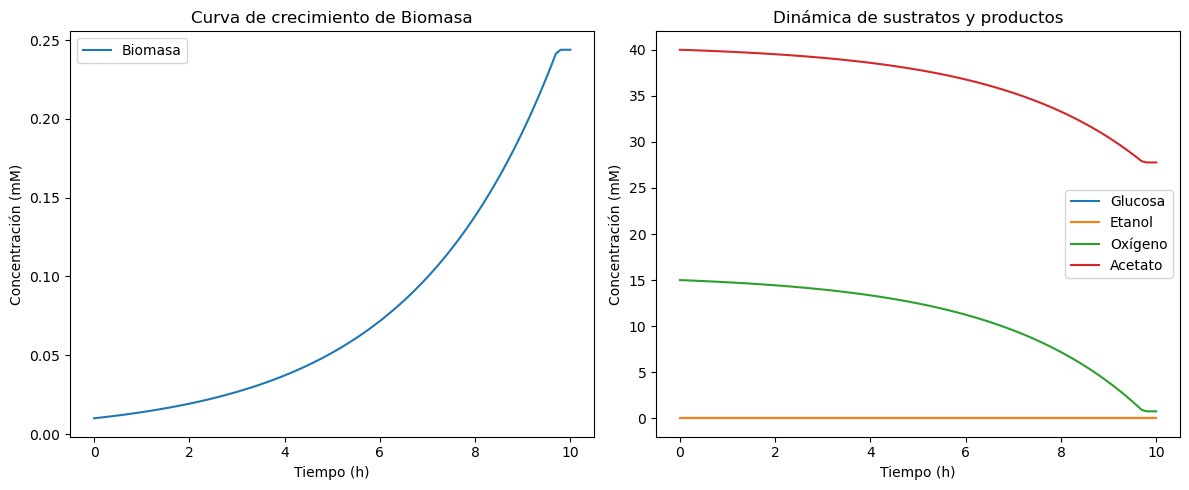

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: Biomasa y Glucosa
axs[0].plot(sol.t, sol.y[0], label='Biomasa')

axs[0].set_xlabel('Tiempo (h)')
axs[0].set_ylabel('Concentración (mM)')
axs[0].legend()
axs[0].set_title('Curva de crecimiento de Biomasa')

# Subplot 2: Oxígeno y Acetato
axs[1].plot(sol.t, sol.y[glucose_exchange_index + 1], label='Glucosa')
axs[1].plot(sol.t, sol.y[etanol_exchange_index + 1], label='Etanol')
axs[1].plot(sol.t, sol.y[oxygen_exchange_index + 1], label='Oxígeno')
axs[1].plot(sol.t, sol.y[acetate_exchange_index + 1], label='Acetato')
axs[1].set_xlabel('Tiempo (h)')
axs[1].set_ylabel('Concentración (mM)')
axs[1].legend()
axs[1].set_title('Dinámica de sustratos y productos')

plt.tight_layout()
plt.show()

**Ventajas DFBA:**
* Incluye información dinámica de todo un crecimiento a diferencia del FBA, que solo es un punto en estado estacionario.
* Es más directo de interpretar concentraciones que fluxes.
* Se pueden ver cambios metabolicos al tener un medio de cultivo con recursos limitados.
